In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
#import seaborn as sns
from scipy.stats import entropy
import copy
from tqdm import tqdm
import pickle
from datetime import datetime

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('../../main_code')))
from main_code.MCMCs import Neal_3, PPMx, PxPPM
from main_code.data_generation import generate_gaussian_mixture
from main_code.visualization import plot_clusters, plot_superclusters

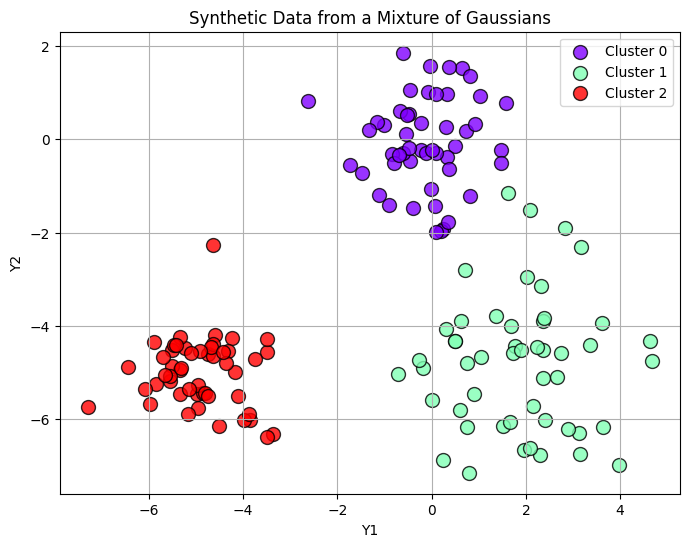

In [3]:
# Sample syntethic
np.random.seed(42)  # for reproducibility
random.seed(42)

# Y
means = [[0, 0], [2, -5], [-5, -5]]
covariances = [np.eye(2), 2 * np.eye(2), 0.5 * np.eye(2)]
n_samples = [50, 50, 50]

Y, labels = generate_gaussian_mixture(means, covariances, n_samples)

plot_clusters(Y, labels, "Synthetic Data from a Mixture of Gaussians", xlabel="Y1", ylabel="Y2")

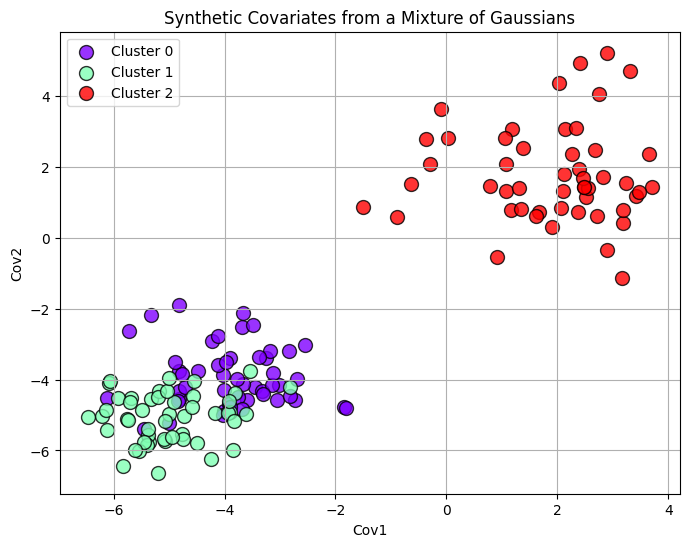

In [4]:
# X
means_X = [[-4, -4], [-5, -5], [2, 2]]
covariances_X = [ np.eye(2), 0.5* np.eye(2), 2 * np.eye(2)]
X, _ = generate_gaussian_mixture(means_X, covariances_X, n_samples)

plot_clusters(X, labels, "Synthetic Covariates from a Mixture of Gaussians", xlabel="Cov1", ylabel="Cov2")

In [5]:
pxppm = PxPPM(alpha=0.1, lamb_0=1)

iter = 500
sub_history, super_history = pxppm.fit(Y=Y, X=X, n_steps=iter)


PxPPM: 100%|██████████| 500/500 [01:22<00:00,  6.08it/s]


In [6]:
best_subs, _ = pxppm.find_optimal_subclustering(burnin=50)
best_super_structure = pxppm.get_hierarchical_structure(best_subs, burnin=50)

Point Estimate Progress: 100%|██████████| 451/451 [00:04<00:00, 93.13step/s] 


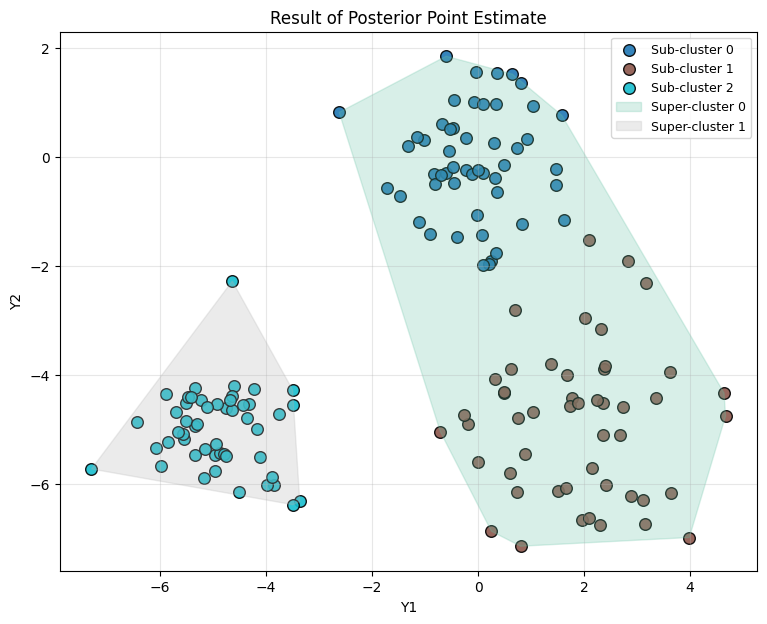

In [7]:
plot_superclusters(Y, best_subs, best_super_structure, "Result of Posterior Point Estimate", xlabel="Y1", ylabel="Y2")